# VGG16 Transfer Learning Training
This notebook trains a VGG16 model with pretrained ImageNet weights on a custom dataset.

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.10.0
GPU Available: []


In [4]:
# Configuration parameters
IMG_SIZE = 224  # VGG16 input size
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.0001

# Dataset paths - MODIFY THESE PATHS
TRAIN_DIR = 'segmented_dataset_split/train'
VALID_DIR = 'segmented_dataset_split/valid'
TEST_DIR = 'segmented_dataset_split/test'

# Model save path
MODEL_SAVE_PATH = 'vgg16_model.h5'

In [5]:
# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get number of classes
num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")
print(f"Class indices: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {valid_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 5188 images belonging to 103 classes.
Found 1114 images belonging to 103 classes.
Found 1114 images belonging to 103 classes.
Number of classes: 103
Class indices: {'1': 0, '10': 1, '100': 2, '101': 3, '102': 4, '103': 5, '11': 6, '12': 7, '13': 8, '14': 9, '15': 10, '16': 11, '17': 12, '18': 13, '19': 14, '2': 15, '20': 16, '21': 17, '22': 18, '23': 19, '24': 20, '25': 21, '26': 22, '27': 23, '28': 24, '29': 25, '3': 26, '30': 27, '31': 28, '32': 29, '33': 30, '34': 31, '35': 32, '36': 33, '37': 34, '38': 35, '39': 36, '4': 37, '40': 38, '41': 39, '42': 40, '43': 41, '44': 42, '45': 43, '46': 44, '47': 45, '48': 46, '49': 47, '5': 48, '50': 49, '51': 50, '52': 51, '53': 52, '54': 53, '55': 54, '56': 55, '57': 56, '58': 57, '59': 58, '6': 59, '60': 60, '61': 61, '62': 62, '63': 63, '64': 64, '65': 65, '66': 66, '67': 67, '68': 68, '69': 69, '7': 70, '70': 71, '71': 72, '72': 73, '73': 74, '74': 75, '75': 76, '76': 77, '77': 78, '78': 79, '79': 80, '8': 81, '80': 82, '81': 83, '82

In [6]:
# Load VGG16 with pretrained ImageNet weights
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the complete model
model = Model(inputs=base_model.input, outputs=predictions)

print(f"Total layers: {len(model.layers)}")
print(f"Trainable layers: {sum([1 for layer in model.layers if layer.trainable])}")
model.summary()

58889256/58889256 [==============================] - 13s 0us/step
Total layers: 25
Trainable layers: 6
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                        

In [7]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("Model compiled successfully!")

Model compiled successfully!


In [8]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_vgg16_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

In [9]:
# Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/50
163/163 [==============================] - ETA: 0s - loss: 4.6212 - accuracy: 0.0239 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 1: val_accuracy improved from -inf to 0.08528, saving model to best_vgg16_model.h5
163/163 [==============================] - 552s 3s/step - loss: 4.6212 - accuracy: 0.0239 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 4.4083 - val_accuracy: 0.0853 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/50
163/163 [==============================] - ETA: 0s - loss: 4.4163 - accuracy: 0.0507 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: val_accuracy improved from 0.08528 to 0.13645, saving model to best_vgg16_model.h5
163/163 [==============================] - 442s 3s/step - loss: 4.4163 - accuracy: 0.0507 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 4.1233 - val_accuracy: 0.1364 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-04
Epoch 3/50
163/163 [==

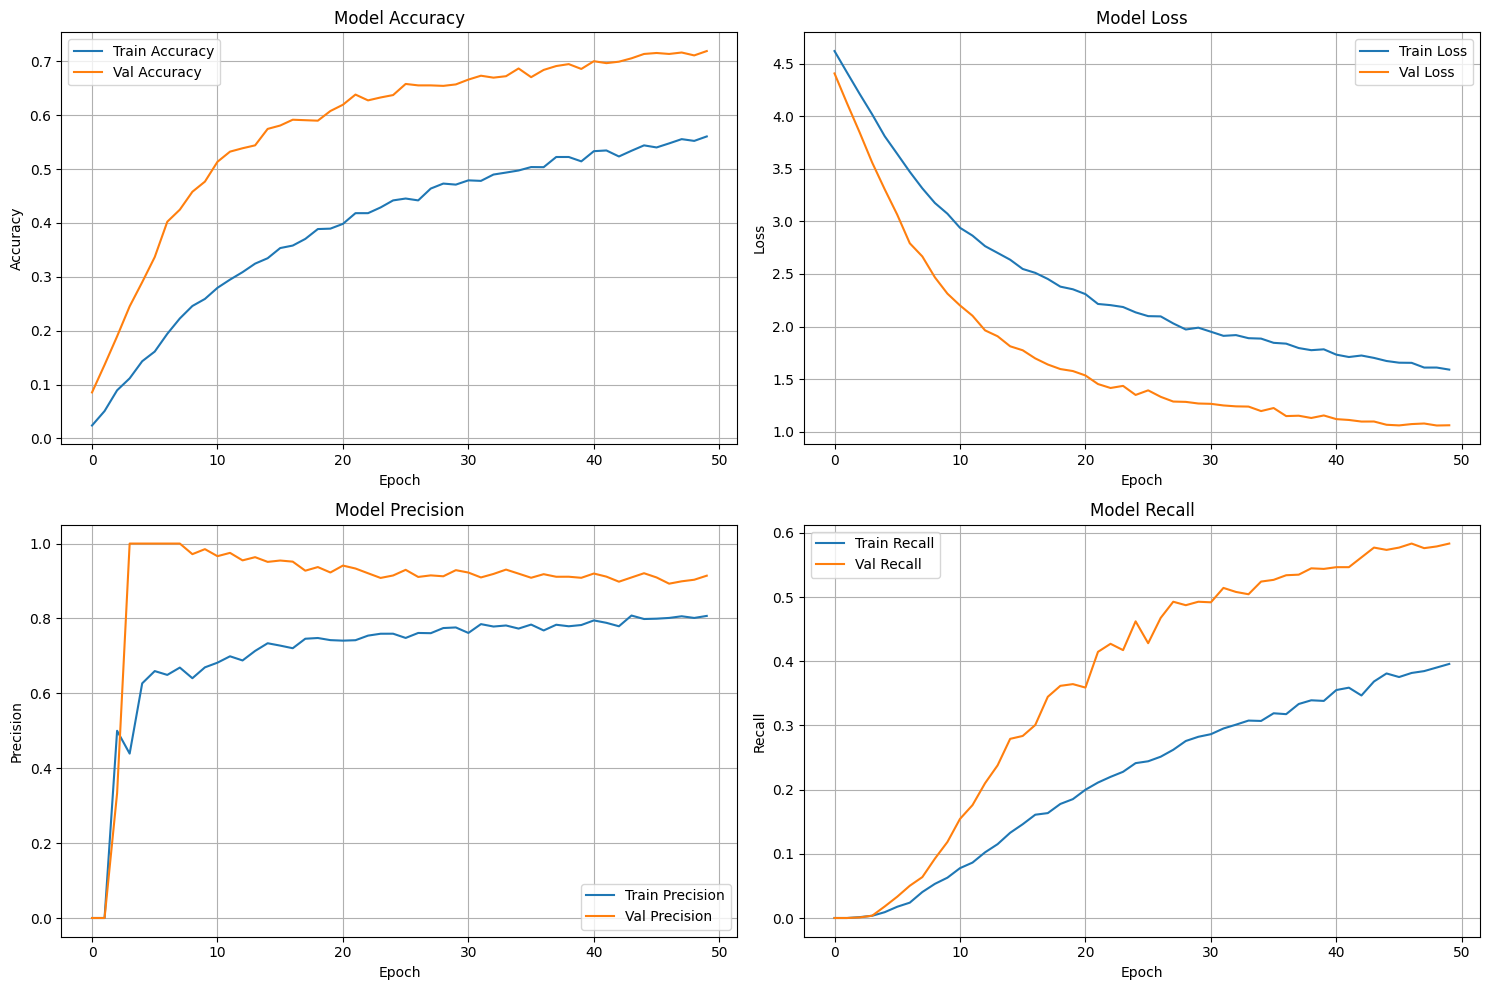

In [10]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train Loss')
axes[0, 1].plot(history.history['val_loss'], label='Val Loss')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('vgg16_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Evaluate on test set
if test_generator is not None:
    print("Evaluating on test set...")
    test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
    print(f"\nTest Results:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")

    print(f"Test F1-Score: {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}")
    print("You can make predictions using: predictions = model.predict(test_images)")

else:    print("Test evaluation skipped - test images loaded without labels")

Evaluating on test set...
35/35 [==============================] - 70s 2s/step - loss: 1.0741 - accuracy: 0.7190 - precision: 0.8983 - recall: 0.5709

Test Results:
Test Loss: 1.0741
Test Accuracy: 0.7190
Test Precision: 0.8983
Test Recall: 0.5709
Test F1-Score: 0.6981
You can make predictions using: predictions = model.predict(test_images)


In [13]:
# Generate predictions for confusion matrix
print("Generating predictions...")
test_generator.reset()
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

print(f"\nPrediction shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")

Generating predictions...
35/35 [==============================] - 68s 2s/step

Prediction shape: (1114, 103)
True labels shape: (1114,)


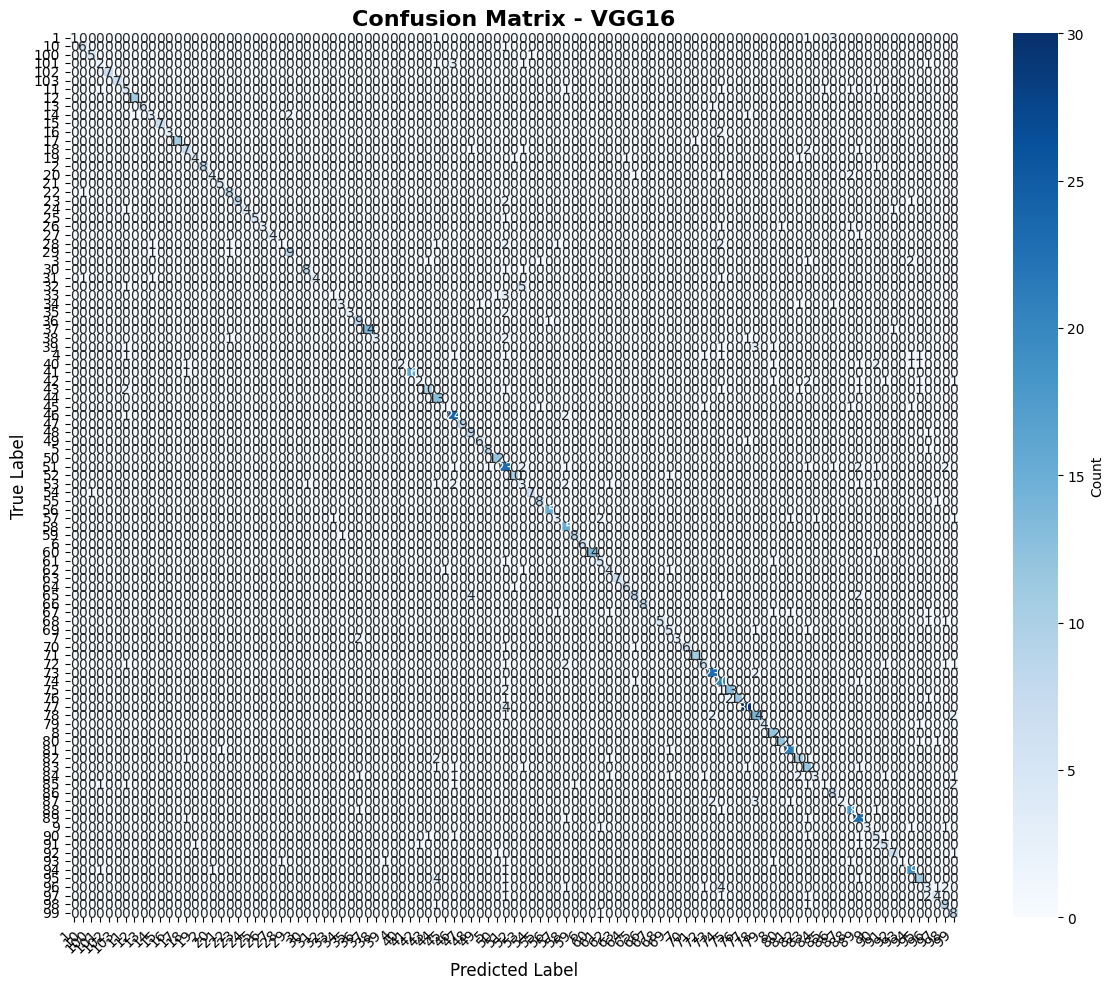

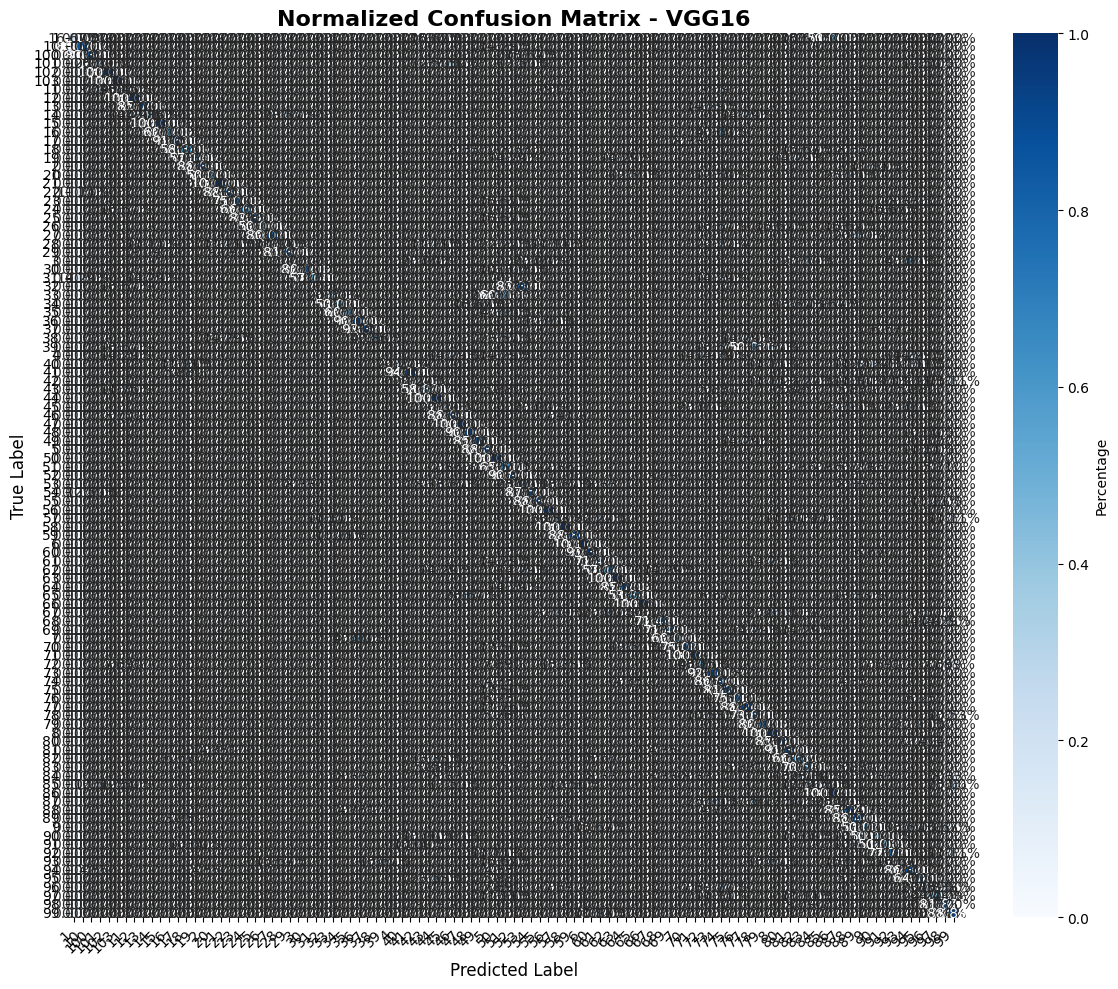

In [14]:
# Create and visualize confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - VGG16', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('vgg16_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - VGG16', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('vgg16_confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Print classification report
print("\nClassification Report:")
print("="*80)
print(classification_report(y_true, y_pred_classes, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.17      0.29         6
          10       0.75      0.86      0.80         7
         100       0.83      0.83      0.83         6
         101       0.40      0.25      0.31         8
         102       1.00      1.00      1.00         7
         103       1.00      1.00      1.00         7
          11       0.36      0.45      0.40        11
          12       0.92      1.00      0.96        11
          13       1.00      0.86      0.92         7
          14       0.50      0.43      0.46         7
          15       1.00      1.00      1.00         7
          16       1.00      0.60      0.75         5
          17       1.00      0.92      0.96        12
          18       0.64      0.58      0.61        12
          19       0.80      0.57      0.67         7
           2       1.00      0.89      0.94         9
          20       0.80      0.50      0.62         8
   

c:\Users\jayad\Desktop\Machine Learning\GPU\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jayad\Desktop\Machine Learning\GPU\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jayad\Desktop\Machine Learning\GPU\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [16]:
# Save the final model
model.save(MODEL_SAVE_PATH)
print(f"\nModel saved successfully to: {MODEL_SAVE_PATH}")

# Save model in TensorFlow SavedModel format (for deployment)
model.save('vgg16_savedmodel', save_format='tf')
print("Model also saved in SavedModel format: vgg16_savedmodel/")

# Save model weights only
model.save_weights('vgg16_weights.h5')
print("Model weights saved: vgg16_weights.h5")


Model saved successfully to: vgg16_model.h5


INFO:tensorflow:Assets written to: vgg16_savedmodel\assets


INFO:tensorflow:Assets written to: vgg16_savedmodel\assets


Model also saved in SavedModel format: vgg16_savedmodel/
Model weights saved: vgg16_weights.h5


In [ ]:
# Optional: Fine-tuning (unfreeze some layers)
# Uncomment the following cells if you want to fine-tune the model

# # Unfreeze the base model
# base_model.trainable = True

# # Fine-tune from this layer onwards (VGG16 has fewer layers than ResNet)
# fine_tune_at = 15

# # Freeze all layers before fine_tune_at
# for layer in base_model.layers[:fine_tune_at]:
#     layer.trainable = False

# # Recompile with lower learning rate
# model.compile(
#     optimizer=Adam(learning_rate=LEARNING_RATE/10),
#     loss='categorical_crossentropy',
#     metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
# )

# # Continue training
# history_fine = model.fit(
#     train_generator,
#     epochs=20,
#     validation_data=valid_generator,
#     callbacks=callbacks,
#     verbose=1
# )

# # Save fine-tuned model
# model.save('vgg16_finetuned.h5')
# print("Fine-tuned model saved!")

## Summary

This notebook successfully:
1. Loaded and preprocessed the dataset from train/valid/test folders
2. Created a VGG16 model with pretrained ImageNet weights
3. Added custom classification layers
4. Trained the model with data augmentation
5. Evaluated performance on test set
6. Generated confusion matrix visualization
7. Saved the trained model in multiple formats

Trying model: efficientnetb0_savedmodel.h5
Skipping incompatible model: efficientnetb0_savedmodel.h5
Trying model: best_vgg16_model.h5
Loaded model: best_vgg16_model.h5


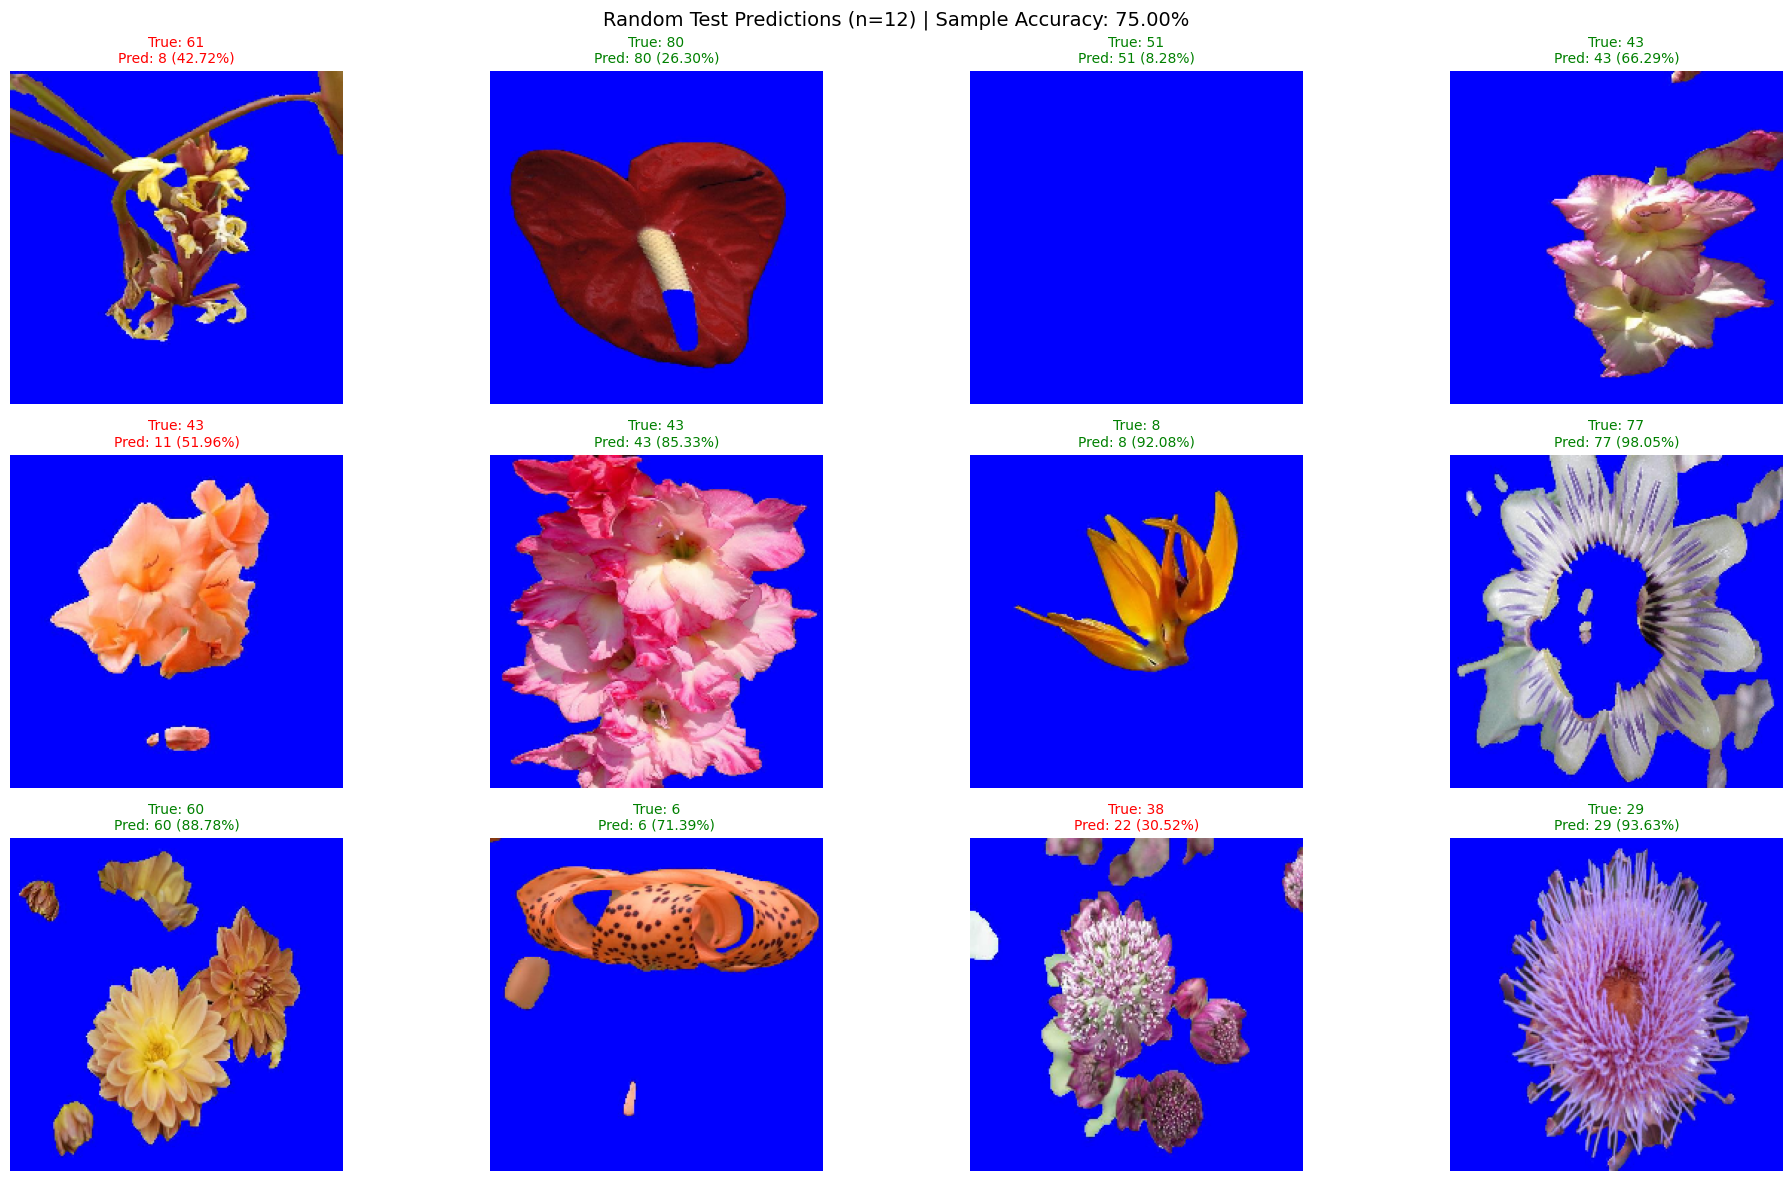

Checked 12 images from: segmented_dataset_split/test
Correct predictions in sample: 9/12 (75.00%)


In [5]:
# Quick inference demo: load saved model and show predictions on random test images
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing import image

# Paths and settings
IMG_SIZE = 224 if 'IMG_SIZE' not in globals() else IMG_SIZE
TEST_DIR = 'segmented_dataset_split/test' if 'TEST_DIR' not in globals() else TEST_DIR
MODEL_PATH = 'efficientnetb0_savedmodel.h5' if 'MODEL_PATH' not in globals() else MODEL_PATH

def _patch_keras3_to_tf210(model_config_obj):
    """Recursively patch common Keras 3 config keys for TF/Keras 2.10 compatibility."""
    if isinstance(model_config_obj, dict):
        class_name = model_config_obj.get('class_name')
        cfg = model_config_obj.get('config', {}) if isinstance(model_config_obj.get('config'), dict) else None

        if class_name == 'InputLayer' and cfg is not None:
            if 'batch_shape' in cfg and 'batch_input_shape' not in cfg:
                cfg['batch_input_shape'] = cfg.pop('batch_shape')
                model_config_obj['config'] = cfg

        if class_name == 'DTypePolicy':
            model_config_obj['class_name'] = 'Policy'

        if class_name == 'BatchNormalization' and cfg is not None:
            cfg.pop('synchronized', None)
            model_config_obj['config'] = cfg

        for _, value in model_config_obj.items():
            _patch_keras3_to_tf210(value)
    elif isinstance(model_config_obj, list):
        for item in model_config_obj:
            _patch_keras3_to_tf210(item)

def load_model_compat(model_path):
    """Load a Keras .h5 model with fallback patches for Keras 3 -> TF/Keras 2.10."""
    try:
        return keras.models.load_model(model_path, compile=False)
    except Exception:
        import h5py
        with h5py.File(model_path, 'r') as f:
            model_config = f.attrs.get('model_config')
            if model_config is None:
                raise ValueError(
                    'Could not read model_config from H5 file. Please load with matching TensorFlow/Keras version.'
                )
            if isinstance(model_config, bytes):
                model_config = model_config.decode('utf-8')

        model_config_obj = json.loads(model_config)
        _patch_keras3_to_tf210(model_config_obj)

        patched_model = keras.models.model_from_config(model_config_obj)
        patched_model.load_weights(model_path)
        return patched_model

# Try EfficientNet first, then VGG checkpoints
candidate_models = [MODEL_PATH, 'best_vgg16_model.h5', 'vgg16_model.h5']
candidate_models = list(dict.fromkeys(candidate_models))  # keep order, remove duplicates

available_models = [p for p in candidate_models if os.path.exists(p)]
if not available_models:
    raise FileNotFoundError('No saved model found. Expected one of: ' + ', '.join(candidate_models))

loaded_model = None
model_path = None
load_errors = []
for p in available_models:
    try:
        print(f'Trying model: {p}')
        loaded_model = load_model_compat(p)
        model_path = p
        print(f'Loaded model: {model_path}')
        break
    except Exception as e:
        load_errors.append(f'{p}: {type(e).__name__}: {e}')
        print(f'Skipping incompatible model: {p}')

if loaded_model is None:
    raise ValueError('Failed to load any available model.\n' + '\n'.join(load_errors))

if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f'Test directory not found: {TEST_DIR}')

# Build class list from test folder structure
class_names = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
if len(class_names) == 0:
    raise ValueError(f'No class folders found inside: {TEST_DIR}')

# Collect image paths with true labels
image_records = []
for cls_idx, cls_name in enumerate(class_names):
    cls_dir = os.path.join(TEST_DIR, cls_name)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
            image_records.append((os.path.join(cls_dir, fname), cls_idx, cls_name))

if len(image_records) == 0:
    raise ValueError(f'No images found under test directory: {TEST_DIR}')

num_samples = min(12, len(image_records))
samples = random.sample(image_records, num_samples)

# Predict and visualize
cols = 4
rows = int(np.ceil(num_samples / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

correct = 0
for i, (img_path, true_idx, true_name) in enumerate(samples):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)

    pred = loaded_model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(pred))
    conf = float(pred[pred_idx])

    pred_name = class_names[pred_idx] if pred_idx < len(class_names) else str(pred_idx)
    is_correct = (pred_idx == true_idx)
    if is_correct:
        correct += 1

    axes[i].imshow(img)
    title_color = 'green' if is_correct else 'red'
    axes[i].set_title(
        f'True: {true_name}\nPred: {pred_name} ({conf:.2%})',
        color=title_color,
        fontsize=10
    )
    axes[i].axis('off')

# Hide any unused subplot axes
for j in range(num_samples, len(axes)):
    axes[j].axis('off')

sample_acc = correct / num_samples
plt.suptitle(f'Random Test Predictions (n={num_samples}) | Sample Accuracy: {sample_acc:.2%}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Checked {num_samples} images from: {TEST_DIR}')
print(f'Correct predictions in sample: {correct}/{num_samples} ({sample_acc:.2%})')